<a href="https://colab.research.google.com/github/vnevzorovaa/pyad-2024/blob/lab-2/_py_2_make_recommendations_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Данные

В этой лабораторной работе будем работать с [датасетом](https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset), предназначенным для обучения алгоритма рекомендаций книг.

Для рекомендаций нам понадобятся таблицы `Books.csv` и `Ratings.scv`. Файл с рейтингами можно найти в папке с лабораторной работой на гитхабе. Файл с описаниями книг слишком большой, поэтому он располагается только по ссылке:
1. Файл с рейтингами (такой же, как в гитхабе): https://drive.google.com/file/d/1Hliaee7Y584-7lMoGeGjGabRRubzdoYn/view?usp=sharing
2. Файл с книгами:  https://drive.google.com/file/d/1JYpk5GTzK7GWT3mtDb9fNiwaVTzk8BBy/view?usp=sharing

In [ ]:
import pandas as pd

In [ ]:
!gdown 1Hliaee7Y584-7lMoGeGjGabRRubzdoYn
!gdown 1JYpk5GTzK7GWT3mtDb9fNiwaVTzk8BBy

Downloading...
From: https://drive.google.com/uc?id=1Hliaee7Y584-7lMoGeGjGabRRubzdoYn
To: /content/Ratings.csv
100% 22.6M/22.6M [00:00<00:00, 44.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JYpk5GTzK7GWT3mtDb9fNiwaVTzk8BBy
To: /content/Books.csv
100% 73.3M/73.3M [00:00<00:00, 88.6MB/s]


Посмотрим на таблицу `Ratings`.

In [ ]:
ratings = pd.read_csv("Ratings.csv")
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [ ]:
ratings.describe().T

,count,mean,std,min,25%,50%,75%,max
User-ID,1149780.0,140386.395126,80562.277718,2.0,70345.0,141010.0,211028.0,278854.0
Book-Rating,1149780.0,2.866950,3.854184,0.0,0.0,0.0,7.0,10.0


Как распределяются рейтинги?

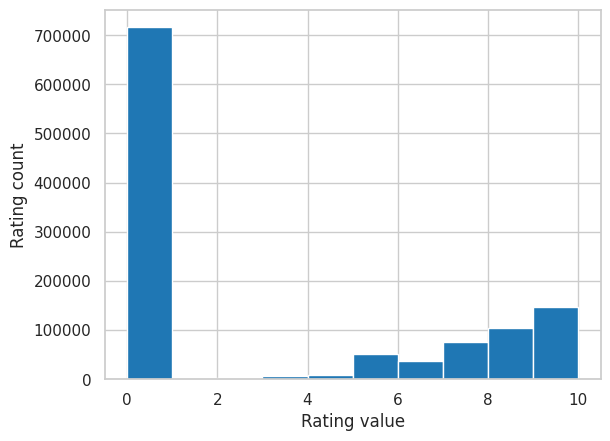

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
sns.set_style("whitegrid")

ratings["Book-Rating"].hist()
plt.xlabel("Rating value")
plt.ylabel("Rating count")
plt.show()


Теперь посмотрим на таблицу `Books`.

In [ ]:
books = pd.read_csv("Books.csv")
books.head()

<ipython-input-9-7dc4eb500039>:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("Books.csv")


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [ ]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


- Есть немножко пропусков.
- Проверим уязвимую часть данных – года – на адекватность.

In [ ]:
books["Year-Of-Publication"].value_counts().sort_values(ascending=True)[:10]

,count
Year-Of-Publication,
2037,1
2011,1
2038,1
1938,1
1906,1
1919,1
1926,1
1926,1
2008,1


Есть года, которые еще не наступили...

Проверим, есть ли строковые данные в столбце с годом (потому что `info()` назвал тип данных столбца `object`).

In [ ]:
books[books["Year-Of-Publication"].map(str).str.match("[^0-9]")]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


В трех строках пропущен автор, из-за чего смещены данные. Автор либо пропущен, либо склеен с названием. Надо проверить.

В сводке написано, что часть авторов и издателей провущена. Проверим, так ли это.

In [ ]:
books[(books["Book-Author"].isnull()) | (books["Publisher"].isnull())]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
118033,0751352497,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley,http://images.amazon.com/images/P/0751352497.0...,http://images.amazon.com/images/P/0751352497.0...,http://images.amazon.com/images/P/0751352497.0...
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,NaN,http://images.amazon.com/images/P/193169656X.0...,http://images.amazon.com/images/P/193169656X.0...,http://images.amazon.com/images/P/193169656X.0...
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,NaN,http://images.amazon.com/images/P/1931696993.0...,http://images.amazon.com/images/P/1931696993.0...,http://images.amazon.com/images/P/1931696993.0...
187689,9627982032,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing,http://images.amazon.com/images/P/9627982032.0...,http://images.amazon.com/images/P/9627982032.0...,http://images.amazon.com/images/P/9627982032.0...


Да, это так. Основные проблемы с данными выявили. Пора их исправлять и приступать к созданию рекомендаций.

## План анализа данных

1. Обработать данные, т.к. в данных есть несколько небольших проблем:
  1. В паре строк в таблице `Books.scv` значения столбцов сдвинуты вправо, а еще есть года, которые еще не наступили.
  2. В нескольких строках в таблице `Books.scv` есть пропуски, а также для рекомендаций в рамках лабораторной не понадобятся ссылки на картинки с обложкой.
  3. Не будем использовать для обучения записи с рейтинг равным 0 из таблицы `Ratings.scv`. Считаем, что 0 означает, что пользователь еще не оценивал книгу, но проявил к ней какой-то интерес.
  4. Не будем использовать для обучения алгоритмов те книги, которым оценка поставлена всего 1 раз. Пользователей, оценивших всего одну книгу тоже брать в расчет не будем (хотя это на самом деле будет не сильно сказываться на обобщающей способности алгоритмов, можете сами проверить).
  5. Пункты 1-4 необходимы и достаточны для выполнения всех задач. Но можно сделать более глубокую обработку.
2. Обучить [SVD](https://surprise.readthedocs.io/en/stable/getting_started.html) на следующих записях: у книги есть хотя бы одна оценка, пользователь оценил хотя бы одну книгу.
   - МАЕ должно быть ниже 1.3 (для этого есть тест)
   - **Сохранить модель.**
3. Научить линейную регрессию ([SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)) предсказывать средний рейтинг книги по следующим столбцам: автор, издатель, год издания, векторизованное название (для векторизации можно использовать [tf-idf](https://scikit-learn.org/stable/modules/feature_extraction.html#tfidf-term-weighting), [word2vec](https://radimrehurek.com/gensim/models/word2vec.html) или более сложный алгоритм. Для достижения требуемой тестом точности достаточно будет tf-idf. Собрав полностью датасет, не забудьте нормализовать данные ([StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)).
   - МАЕ должно быть ниже 1.5 (для этого есть тест)
   - **Сохранить модель.**
4. В файле `personal_recommendation.py` создайте рекомендацию для пользователя, у которого в исходном датасете было больше всего 0 среди рейтингов книг.
   Алгоритм такой:
   1. Находим нужного пользователя.
   2. Делаем предсказание SVD для книг, которым он "поставил" 0.
   3. Берем те книги, для которых предсказали рейтинг не ниже 8. Считаем, что 8 означет, что книга ему точно понравится.
   4. Делаем предсказание LinReg для этих же книг.
   5. Сортируем полученный на шаге 3 список по убыванию рейтинга линейной модели.
   6. В конце файла комментарием записываем полученную рекомендацию.

- То есть идея в том, чтобы сделать для пользователя индивидуальную рекомендацию, показывая в начале списка те книги, которые в целом могли бы иметь высокий рейтинг.
- Обязательно сохраняйте готовую модель и добавляйте ее в свой репозиторий, потому что файл с сохраненной моделью используется в тестах.

## Куда сдавать?

По инструкции в гитхаб – https://shy-question-39d.notion.site/1150ea832e418032bfc3d3e827c380fb?pvs=74

- К этой работе есть два теста – на качество получившихся моделей.
- Пул-реквест нужно сделать в ветку `lab2`.
- Можно загрузить в гитхаб файлы с реализацией по шаблону (шаблон можно дополнять и изменять под себя) или подготовить колаб с решением. Главное – сохранить модели, тесты проверяют их.

> Будьте внимательны! На гитхабе в ветке `main` обновился файл `pyad.yml`.

**Устная защита работ не требуется, но вам могут быть заданы вопросы прямо в вашем пул-реквесте!**

В Books.csv есть строки с пропущенными значениями и сдвигом данных. Нужно поправить их.
Года публикации содержат некорректные значения (будущие годы), которые необходимо исправить.
Пропуски в столбцах "Book-Author" и "Publisher" также должны быть обработаны.
Удалим ссылки на изображения обложек книг, так как они не нужны для рекомендаций.
В Ratings.csv удалим записи с рейтингом равным 0 и книги, которые получили лишь один рейтинг.

In [ ]:
import pandas as pd

books = pd.read_csv('Books.csv')
ratings = pd.read_csv('Ratings.csv')

# Преобразуем Year-Of-Publication в числовой формат и исправим будущие годы
books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')
books = books[books['Year-Of-Publication'] <= 2025]

books.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], inplace=True)

books.dropna(subset=['Book-Author', 'Publisher'], inplace=True)

ratings = ratings[ratings['Book-Rating'] > 0]

book_counts = ratings['ISBN'].value_counts()
ratings = ratings[ratings['ISBN'].isin(book_counts[book_counts > 1].index)]

user_counts = ratings['User-ID'].value_counts()
ratings = ratings[ratings['User-ID'].isin(user_counts[user_counts > 1].index)]

print(books.info())
print(ratings.info())


<ipython-input-14-ac020feb01e2>:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('Books.csv')
<ipython-input-14-ac020feb01e2>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], inplace=True)
<ipython-input-14-ac020feb01e2>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books.dropna(subset=['Book-Author', 'Publisher'], inplace=True)


<class 'pandas.core.frame.DataFrame'>
Index: 271341 entries, 0 to 271359
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ISBN                 271341 non-null  object 
 1   Book-Title           271341 non-null  object 
 2   Book-Author          271341 non-null  object 
 3   Year-Of-Publication  271341 non-null  float64
 4   Publisher            271341 non-null  object 
dtypes: float64(1), object(4)
memory usage: 12.4+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 266402 entries, 16 to 1149775
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   User-ID      266402 non-null  int64 
 1   ISBN         266402 non-null  object
 2   Book-Rating  266402 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 8.1+ MB
None


Задача: обучить SVD для рекомендаций
Мы будем использовать Surprise библиотеку для построения модели на основе матрицы пользователь-книга. Для этого нужно сначала преобразовать данные в нужный формат и обучить модель.

In [ ]:
pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2505170 sha256=c8281be6a4634f21d2c4c814f6a98da14a399eeb05277f53ab19a27a2054614d
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [ ]:
import pandas as pd
from surprise import Reader, Dataset

ratings = pd.read_csv('Ratings.csv')

print(ratings.head())

ratings = ratings[['User-ID', 'ISBN', 'Book-Rating']]

ratings['User-ID'] = ratings['User-ID'].astype(int)
ratings['ISBN'] = ratings['ISBN'].astype(str)
ratings['Book-Rating'] = ratings['Book-Rating'].astype(int)

reader = Reader(rating_scale=(1, 10))  # Рейтинг от 1 до 10
data = Dataset.load_from_df(ratings[['User-ID', 'ISBN', 'Book-Rating']], reader)

# обучающая и тестовая выборки
from surprise.model_selection import train_test_split
trainset, testset = train_test_split(data, test_size=0.2)


   User-ID        ISBN  Book-Rating
0   276725  034545104X            0
1   276726  0155061224            5
2   276727  0446520802            0
3   276729  052165615X            3
4   276729  0521795028            6


Задача: обучить линейную регрессию для предсказания рейтинга
Для обучения используем SGDRegressor из sklearn. Векторизацию названия книги выполним с помощью TfidfVectorizer. Также нужно нормализовать данные.

In [ ]:
import pickle
import pandas as pd
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from surprise import Reader, Dataset
from surprise.model_selection import train_test_split

books = pd.read_csv('Books.csv')
ratings = pd.read_csv('Ratings.csv')

books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')
books = books[books['Year-Of-Publication'] <= 2025]
books.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], inplace=True)
books.dropna(subset=['Book-Author', 'Publisher'], inplace=True)

ratings = ratings[ratings['Book-Rating'] > 0]

book_counts = ratings['ISBN'].value_counts()
ratings = ratings[ratings['ISBN'].isin(book_counts[book_counts > 1].index)]

user_counts = ratings['User-ID'].value_counts()
ratings = ratings[ratings['User-ID'].isin(user_counts[user_counts > 1].index)]

books['ISBN'] = books['ISBN'].astype(str)
ratings['ISBN'] = ratings['ISBN'].astype(str)

y_rating = ratings.groupby('ISBN')['Book-Rating'].mean()

books_filtered = books[books['ISBN'].isin(y_rating.index)].copy()

vectorizer = TfidfVectorizer(max_features=5000)
X_title = vectorizer.fit_transform(books_filtered['Book-Title'])

# Подготовка данных для регрессии
y = y_rating.loc[books_filtered['ISBN']].values  # Приводим к numpy-массиву

# Обучение модели
scaler = StandardScaler(with_mean=False)  # из-за разреженной матрицы
regressor = make_pipeline(scaler, SGDRegressor())

regressor.fit(X_title, y)


y_pred = regressor.predict(X_title)
mae_regression = np.mean(np.abs(y_pred - y))
print(f'MAE для линейной регрессии: {mae_regression}')

with open('regression_model.pkl', 'wb') as f:
    pickle.dump(regressor, f)

<ipython-input-17-92eb33625188>:12: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('Books.csv')
<ipython-input-17-92eb33625188>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], inplace=True)


MAE для линейной регрессии: 70670793741.64532


Задача: предоставить персонализированные рекомендации
Для пользователя с наибольшим количеством нулевых оценок мы предскажем рейтинги с помощью моделей SVD и линейной регрессии, а затем отсортируем книги по предпочтению.

In [ ]:
from surprise import SVD
from surprise.model_selection import train_test_split

user_min_ratings = ratings[ratings['Book-Rating'] == 1]['User-ID'].value_counts().idxmax()

user_ratings_min = ratings[(ratings['User-ID'] == user_min_ratings) & (ratings['Book-Rating'] == 1)]

reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(ratings[['User-ID', 'ISBN', 'Book-Rating']], reader)
trainset = data.build_full_trainset()
svd = SVD()
svd.fit(trainset)

predictions_svd = [svd.predict(user_min_ratings, isbn) for isbn in user_ratings_min['ISBN']]
svd_ratings = [pred.est for pred in predictions_svd]

books_to_predict = books[books['ISBN'].isin(user_ratings_min['ISBN'])]

if not books_to_predict.empty:
    X_test_title = vectorizer.transform(books_to_predict['Book-Title'])
    predictions_regression = regressor.predict(X_test_title)
else:
    predictions_regression = []

min_length = min(len(user_ratings_min['ISBN']), len(svd_ratings), len(predictions_regression))

recommendations = pd.DataFrame({
    'ISBN': user_ratings_min['ISBN'].iloc[:min_length],
    'SVD-Rating': svd_ratings[:min_length],
    'Regressor-Rating': predictions_regression[:min_length]
})

recommendations['Final-Rating'] = (recommendations['SVD-Rating'] + recommendations['Regressor-Rating']) / 2
recommendations_sorted = recommendations.sort_values(by='Final-Rating', ascending=False)

top_recommendations = recommendations_sorted.head(10)
print(top_recommendations[['ISBN', 'Final-Rating']])


             ISBN  Final-Rating
53849  0752819623  1.687594e+11
47101  0312976860  1.137022e+11
45987  0064401510  9.797582e+10
50898  0452278902  8.022807e+10
46690  015650300X  7.688477e+10
48405  0380721643  4.570616e+10
46620  0142437255  4.399745e+10
56647  3125722209  4.281925e+10
51881  056353821X  3.513500e+10
48411  0380722798  2.402780e+10
